In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras import Model
from time import time
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

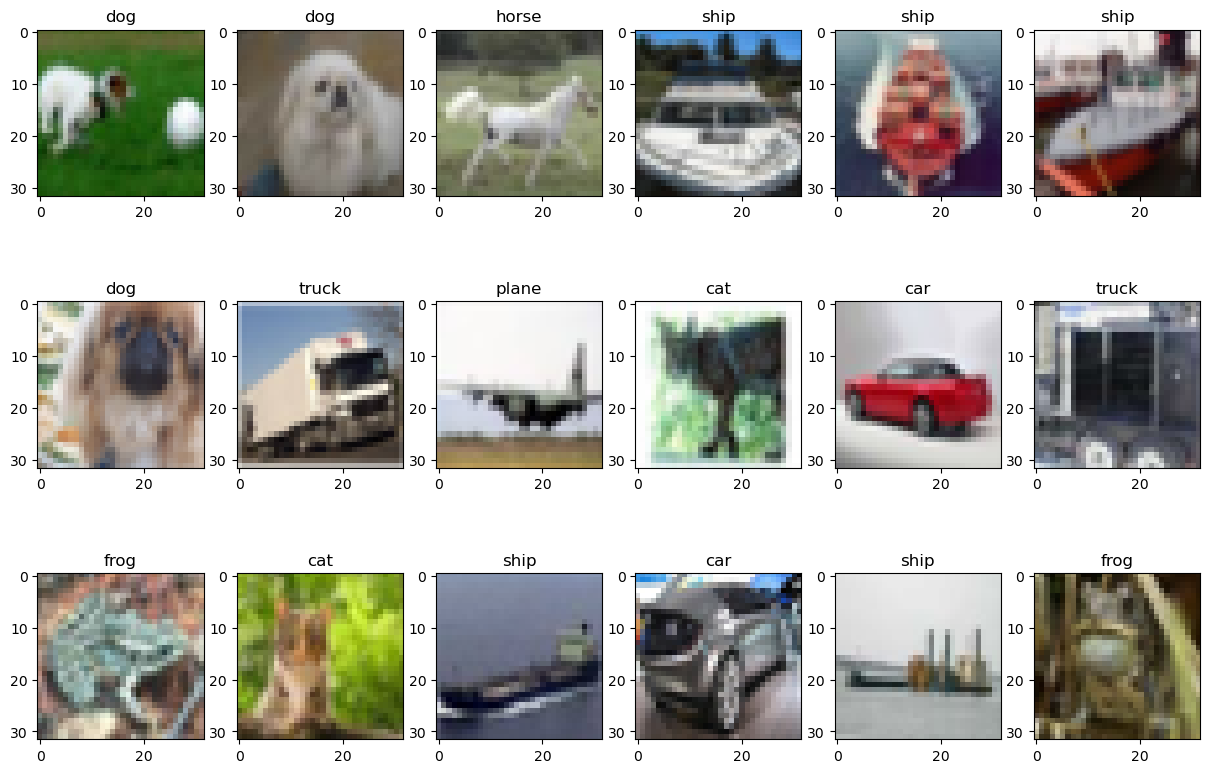

In [12]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Mapping from class ID to class name
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

# Dataset params
num_classes = len(classes)
size = x_train.shape[1]

# Visualize random samples (as a plot with 3x6 samples)
for ii in range(18):    
    plt.subplot(3,6,ii+1)
    # Pick a random sample
    idx =  np.random.randint(0, len(y_train))
    # Show the image and the label
    plt.imshow(x_train[idx, ...])
    plt.title(classes[int(y_train[idx][0])])

(Text(0.5, 0, 'Class ID'), Text(0, 0.5, 'counts'))

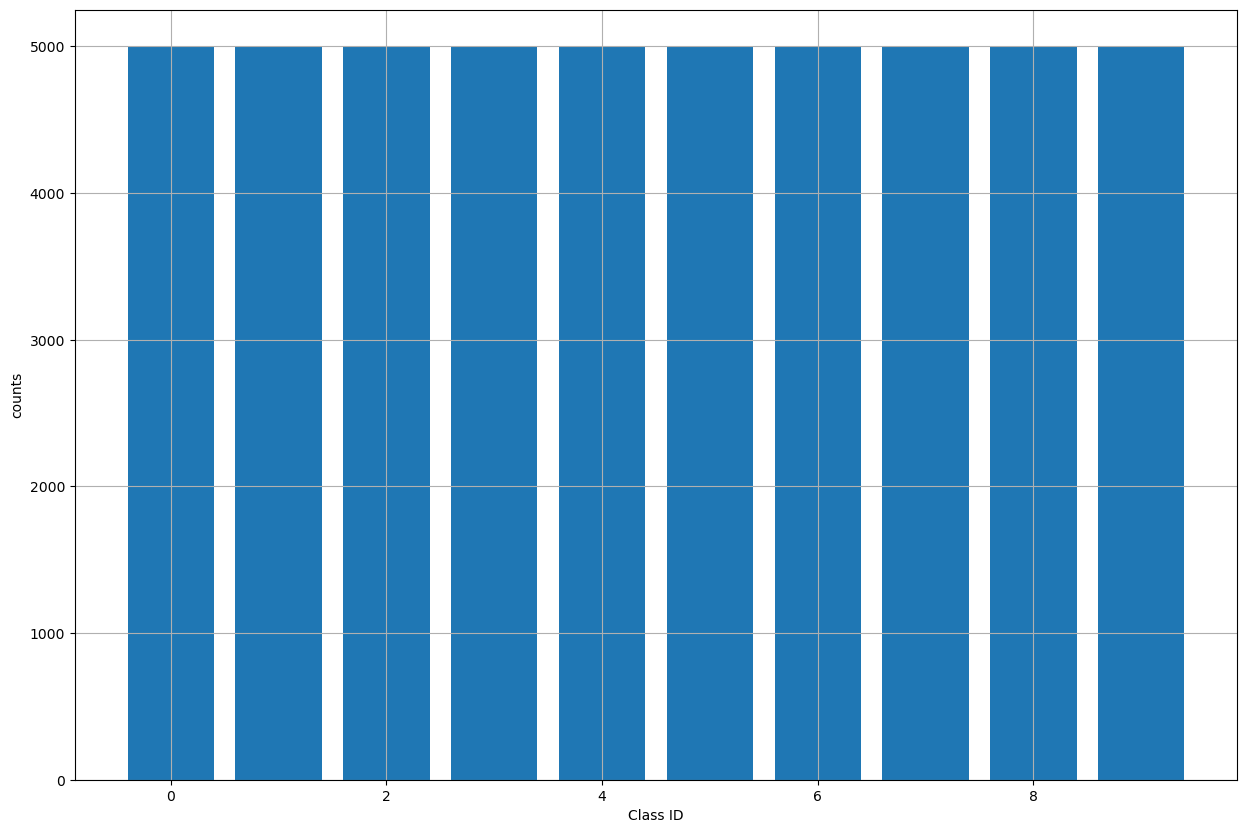

In [13]:
centers = np.arange(0, num_classes + 1)
counts, bounds = np.histogram(y_train, bins=centers-0.5)

plt.bar(centers[:-1], counts), plt.grid(True)
plt.xlabel('Class ID'), plt.ylabel('counts')

(Text(0.5, 0, 'Class ID'), Text(0, 0.5, 'counts'))

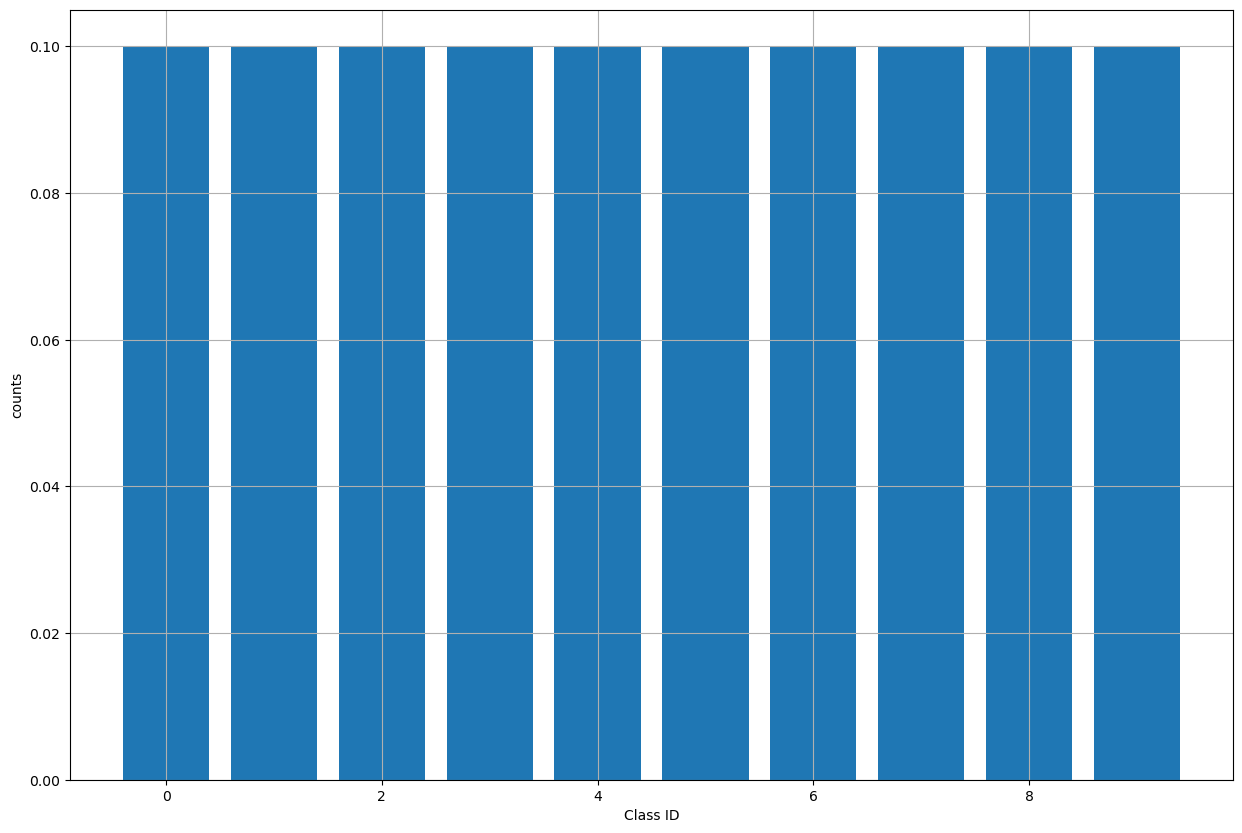

In [14]:
plt.bar(centers[:-1], counts/np.sum(counts)), plt.grid(True)
plt.xlabel('Class ID'), plt.ylabel('counts')

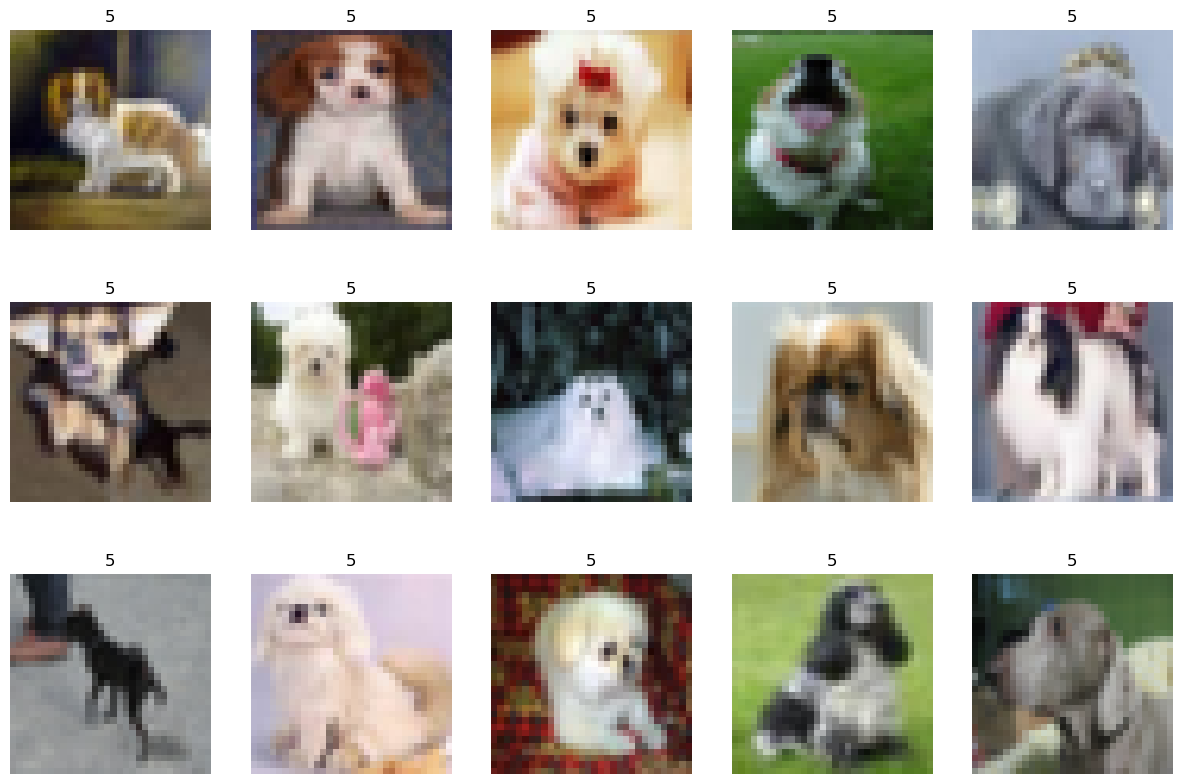

In [15]:
y_train = y_train.flatten()
y_test = y_test.flatten()

# Locate the samples for a given Class ID
class_id = 5
mask = y_train == class_id

# Extract the samples with the given Class ID
y_train_ = y_train[mask]
x_train_ = x_train[mask]

# Plot random samples with class ID
for ii in range(15):
    idx = np.random.randint(0, len(y_train_))
    plt.subplot(3, 5, ii+1)
    plt.imshow(x_train_[idx])
    plt.title(y_train_[idx])
    plt.axis('off')

In [16]:
x_train.shape
y_train.shape

(50000,)

In [17]:
x_train.shape

(50000, 32, 32, 3)

In [18]:
y_train.shape

(50000,)

In [19]:
x_train = x_train/255
x_test = x_test/255
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)
print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


In [20]:
inputs = Input(shape=(size, size, 3))

net = Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
net = BatchNormalization()(net)
net = Conv2D(32, (3, 3), padding='same', activation='relu')(net)
net = BatchNormalization()(net)
net = MaxPooling2D((2, 2))(net)
net = Dropout(0.25)(net)

net = Conv2D(64, (3, 3), padding='same', activation='relu')(net)
net = BatchNormalization()(net)
net = Conv2D(64, (3, 3), padding='same', activation='relu')(net)
net = BatchNormalization()(net)
net = MaxPooling2D((2, 2))(net)
net = Dropout(0.30)(net)

net = Conv2D(128, (3, 3), padding='same', activation='relu')(net)
net = BatchNormalization()(net)
net = Conv2D(128, (3, 3), padding='same', activation='relu')(net)
net = BatchNormalization()(net)
net = MaxPooling2D((2, 2))(net)
net = Dropout(0.35)(net)

net = GlobalAveragePooling2D()(net)
net = Dense(128, activation='relu')(net)
net = Dropout(0.5)(net)

outputs = Dense(num_classes, activation='softmax')(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 306,602 (1.17 MB)

 Trainable params: 305,706 (1.17 MB)

 Non-trainable params: 896 (3.50 KB)

In [21]:
epochs = 50
batch_size = 128

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)
start = time()
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)
print('Elapsed time', time() - start)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 112s 304ms/step - accuracy: 0.4323 - loss: 1.5629 - val_accuracy: 0.1774 - val_loss: 3.1978 - learning_rate: 0.0010
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 144s 309ms/step - accuracy: 0.5968 - loss: 1.1446 - val_accuracy: 0.6352 - val_loss: 1.0254 - learning_rate: 0.0010
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 140s 303ms/step - accuracy: 0.6556 - loss: 0.9852 - val_accuracy: 0.6998 - val_loss: 0.8631 - learning_rate: 0.0010
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 107s 304ms/step - accuracy: 0.6944 - loss: 0.8781 - val_accuracy: 0.7170 - val_loss: 0.7968 - learning_rate: 0.0010
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 142s 303ms/step - accuracy: 0.7232 - loss: 0.7973 - val_accuracy: 0.7558 - val_loss: 0.6952 - learning_rate: 0.0010
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 109s 310ms/step - accuracy: 0.7474 - loss: 0.7331 - val_accuracy: 0.7300 - val_loss: 0.8036 - learning_rate: 0.0010
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 140s 304ms/step - accura

NameError: name 'start' is not defined

Train Acc      0.9410222172737122
Validation Acc 0.8690000176429749


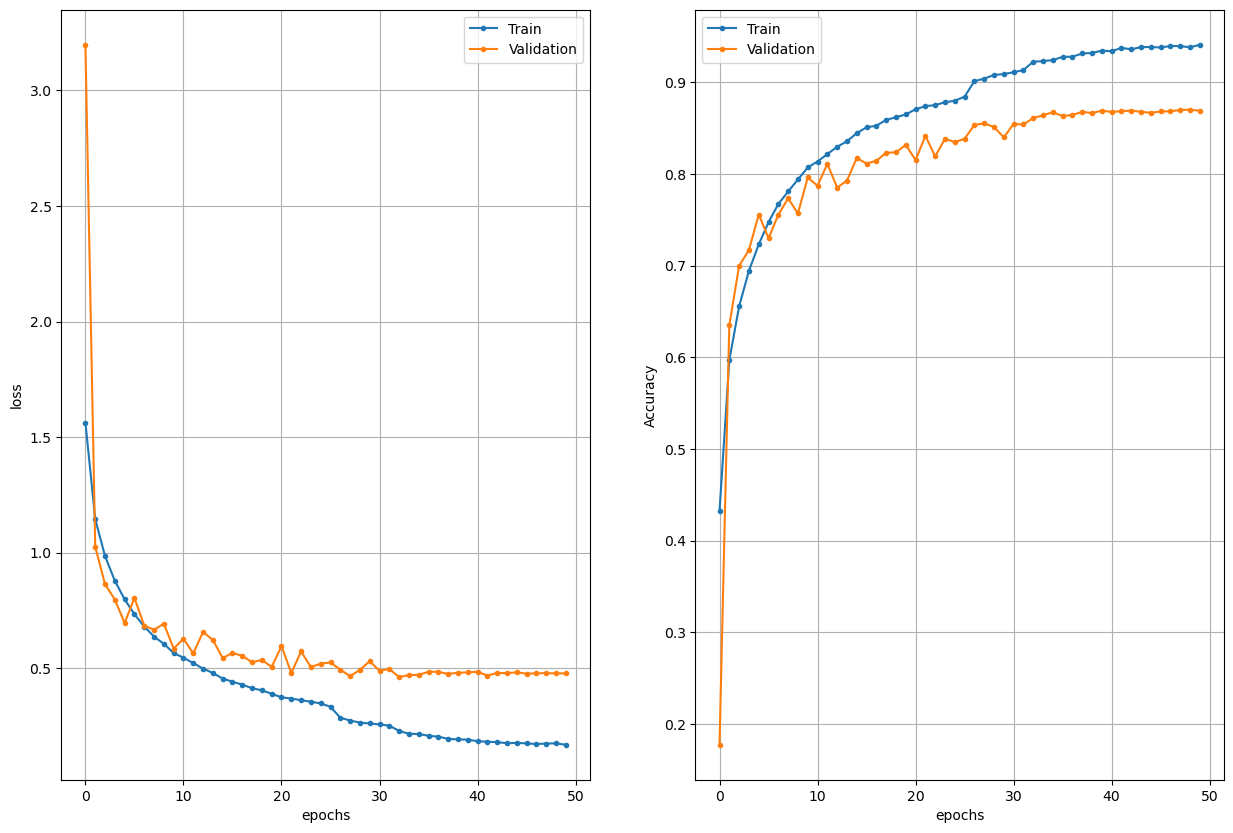

In [22]:
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])    

In [23]:
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


In [24]:
for class_id, class_name in classes.items():
    mask = y_true == class_id
    acc = np.mean(y_pred[mask] == y_true[mask])
    print(class_name, acc)

plane 0.881
car 0.935
bird 0.792
cat 0.661
deer 0.894
dog 0.808
frog 0.932
horse 0.896
ship 0.929
truck 0.915


In [25]:
ev = model.evaluate(x_test, y_test)
print('Test loss : ', ev[0])
print('Test metric : ', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8643 - loss: 0.4976
Test loss :  0.4975760877132416
Test metric :  0.864300012588501


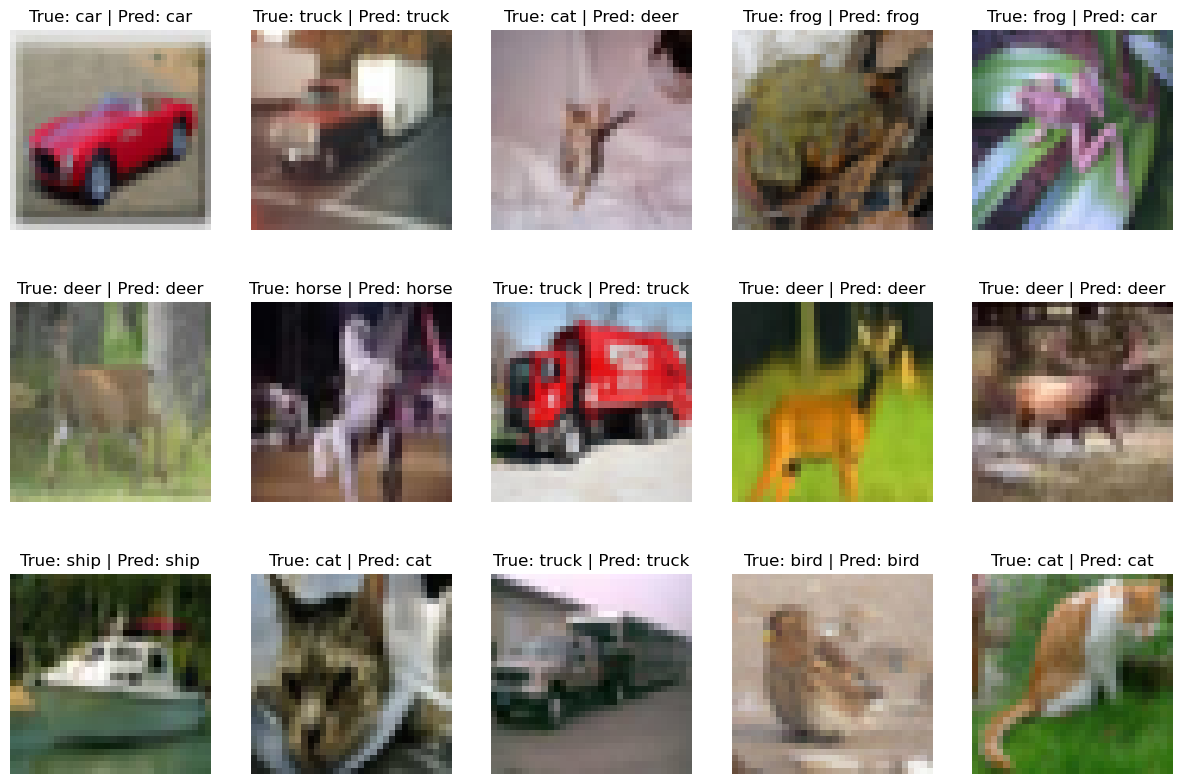

In [26]:
for ii in range(15):
    idx = np.random.randint(0, len(x_test))
    plt.subplot(3, 5, ii+1)
    plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(classes[y_true[idx]]) + ' | Pred: ' + str(classes[y_pred[idx]]))
    plt.axis('off')

In [ ]:
#1.The overall accuracy of the classifier on the test set is 86.43%
#2.deeper CNN architecture,Batch Normalization, apply Dropout to reduce overfitting, and use data augmentation to improve generalization.
#3.Yes. I modified the model by making the CNN deeper and using Batch Normalization, Dropout, and data augmentation. After retraining the classifier, the test accuracy improved from about 80.3% to 86.43%.But to be honest, I added a lot of stuff and made the network more complex, but I only managed to achieve a 6% improvement. That’s why I don’t see the point in increasing the number of epochs. Make the network even more complex?I encountered a time() - start error, but I didn't restart the network; I fixed it instead.